Training model...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9126 - loss: 0.2981 - val_accuracy: 0.9587 - val_loss: 0.1412
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9575 - loss: 0.1449 - val_accuracy: 0.9664 - val_loss: 0.1059
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9675 - loss: 0.1093 - val_accuracy: 0.9740 - val_loss: 0.0844
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9729 - loss: 0.0884 - val_accuracy: 0.9759 - val_loss: 0.0776
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9758 - loss: 0.0768 - val_accuracy: 0.9756 - val_loss: 0.0790
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9791 - loss: 0.0655 - val_accuracy: 0.9788 - val_loss: 0.0712
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9807 - loss: 0.0584 - val_accuracy: 0.9787 - val_loss: 0.0690
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0

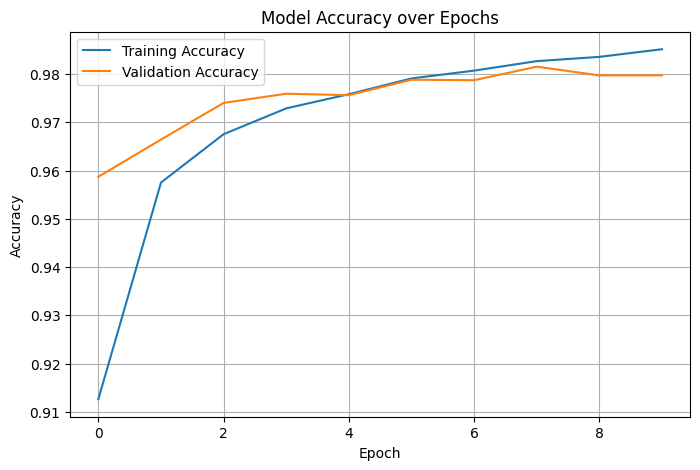

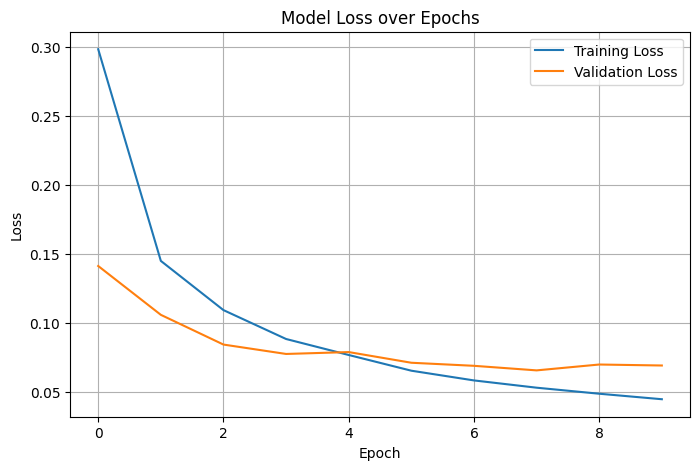

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


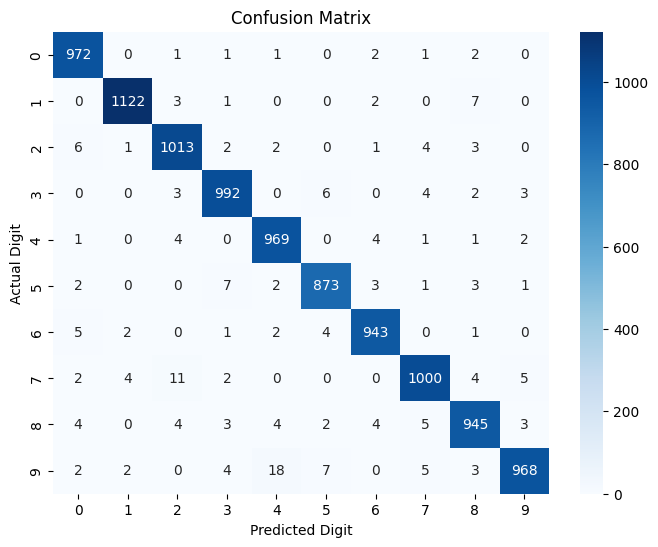

Showing random predictions from the test dataset...


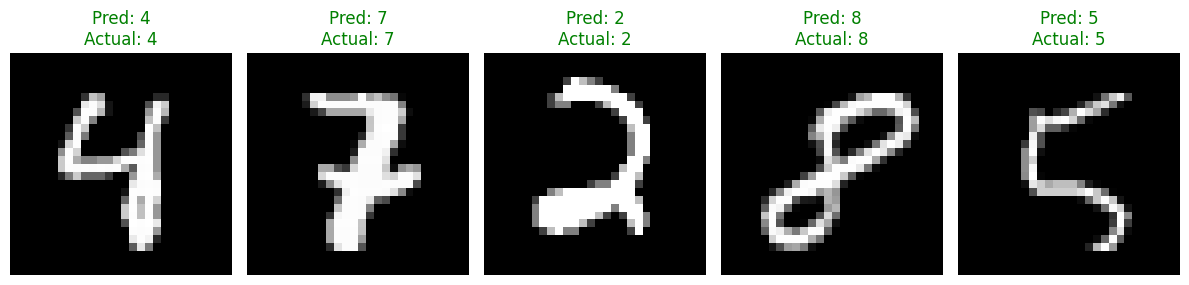

Generating 3D Loss Landscape (this may take 10-20 seconds)...


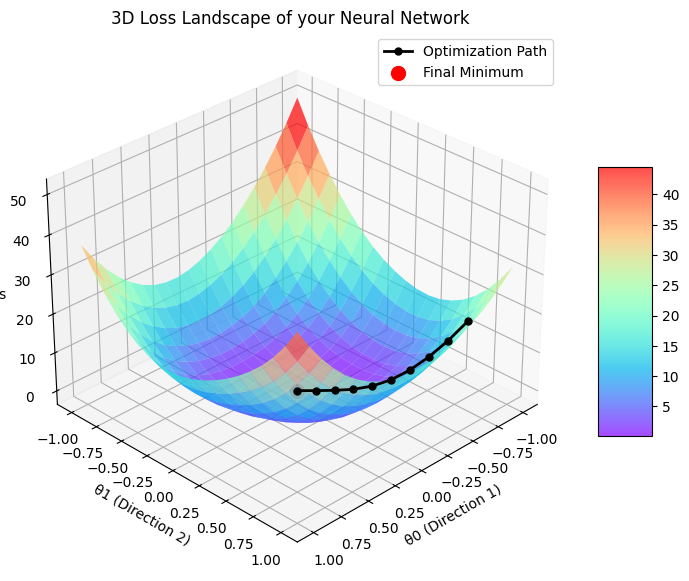

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import cv2
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------------- 1. LOAD AND PREPARE DATA ----------------

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Keep a copy of the 2D test images for visualization later
x_test_images = x_test.copy()

# Flatten images from 28x28 grid into a 1D array of 784 pixels
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# ---------------- 2. BUILD AND TRAIN THE MODEL ----------------

model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
print("Training model...")
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

print("Model Ready!")

# ---------------- 3. ACCURACY GRAPH ----------------

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.title("Model Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# ---------------- 4. LOSS GRAPH ----------------

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Model Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# ---------------- 5. CONFUSION MATRIX ----------------

# Make predictions on the entire test dataset
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.show()


# ---------------- 6. VISUALIZE INDIVIDUAL PREDICTIONS ----------------

print("Showing random predictions from the test dataset...")
plt.figure(figsize=(12, 5))

# Pick 5 random images from the test set
random_indices = np.random.choice(len(x_test), 5, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(1, 5, i + 1)

    # Display the 2D image
    plt.imshow(x_test_images[idx], cmap='gray')

    # Determine text color (green for correct, red for incorrect)
    actual_label = y_test[idx]
    predicted_label = predicted_labels[idx]
    color = "green" if predicted_label == actual_label else "red"

    plt.title(f"Pred: {predicted_label}\nActual: {actual_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()


# ---------------- 7. PREDICT A CUSTOM IMAGE WITH OpenCV ----------------
def predict_my_digit(image_path, trained_model):
    """
    Function to test the model against your own custom handwritten digits!
    """
    print(f"\nAttempting to predict custom image: {image_path}")
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not find image at '{image_path}'.")
        return
    img_resized = cv2.resize(img, (28, 28))
    if np.mean(img_resized) > 127:
        img_resized = cv2.bitwise_not(img_resized)
    img_flattened = (img_resized / 255.0).reshape(1, 784)
    prediction = trained_model.predict(img_flattened)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Model Predicts: {predicted_digit}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()


# ---------------- 8. 3D LOSS LANDSCAPE VISUALIZATION ----------------

print("Generating 3D Loss Landscape (this may take 10-20 seconds)...")

# 1. Get current trained weights
original_weights = model.get_weights()

# 2. Create two random directions to project onto
direction1 = [np.random.randn(*w.shape) * 0.5 for w in original_weights]
direction2 = [np.random.randn(*w.shape) * 0.5 for w in original_weights]

# 3. Create a grid of mathematical coordinates
grid_size = 20
alphas = np.linspace(-1.0, 1.0, grid_size)
betas = np.linspace(-1.0, 1.0, grid_size)
A, B = np.meshgrid(alphas, betas)
losses = np.zeros_like(A)

# Use a small subset of test data so it computes faster (1,000 images)
x_subset = x_test[:1000]
y_subset = y_test[:1000]

# 4. Evaluate the neural network at each point in the grid
for i in range(grid_size):
    for j in range(grid_size):
        a, b = A[i, j], B[i, j]
        # Shift the weights in the random directions
        new_weights = [
            w + a * d1 + b * d2
            for w, d1, d2 in zip(original_weights, direction1, direction2)
        ]
        model.set_weights(new_weights)

        # Calculate loss directly
        predictions_subset = model(x_subset, training=False)
        cce = keras.losses.SparseCategoricalCrossentropy()
        loss = cce(y_subset, predictions_subset).numpy()
        losses[i, j] = loss

# Restore original trained weights!
model.set_weights(original_weights)

# 5. Simulate a gradient descent path dropping into the minimum
path_alphas = np.linspace(-0.8, 0, 10)
path_betas = np.linspace(0.8, 0, 10)
path_losses = []
for a, b in zip(path_alphas, path_betas):
    new_weights = [w + a * d1 + b * d2 for w, d1, d2 in zip(original_weights, direction1, direction2)]
    model.set_weights(new_weights)
    pred_subset = model(x_subset, training=False)
    path_losses.append(cce(y_subset, pred_subset).numpy())
model.set_weights(original_weights)

# 6. Plot the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D Loss Surface
surf = ax.plot_surface(A, B, losses, cmap='rainbow', alpha=0.7)

# Plot the simulated optimization path
ax.plot(path_alphas, path_betas, path_losses, color='black', marker='o', linewidth=2, markersize=5, zorder=5, label='Optimization Path')

# Plot the optimum (the trained model location at 0,0)
ax.scatter([0], [0], [path_losses[-1]], color='red', s=100, zorder=10, label='Final Minimum')

ax.set_title("3D Loss Landscape of your Neural Network")
ax.set_xlabel("θ0 (Direction 1)")
ax.set_ylabel("θ1 (Direction 2)")
ax.set_zlabel("Loss")
ax.view_init(elev=30, azim=45) # Set camera angle
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.legend()
plt.show()
